# 1. Data Preparation & Exploratory Data Analysis (EDA)
Dataset: [RAVDESS Emotional Speech Audio](https://www.kaggle.com/datasets/uwrfkaggler/ravdess-emotional-speech-audio) from Kaggle.

**Cara setup Kaggle Credentials:**
1. Buka https://www.kaggle.com → Settings → API → **Create New API Token**
2. Isi `KAGGLE_USERNAME` dan `KAGGLE_KEY` di file `.env` (satu level di atas folder `notebooks/`)
3. Jalankan notebook dari atas secara berurutan

In [10]:
import os, glob, json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display
import IPython.display as ipd
from dotenv import load_dotenv

plt.style.use('ggplot')
%matplotlib inline

print('Libraries loaded successfully.')

Libraries loaded successfully.


## Step 1: Load Kaggle Credentials dari `.env`

In [11]:
# Load dari file .env (relatif dari folder notebooks/)
env_path = os.path.abspath(os.path.join(os.getcwd(), '..', '.env'))
load_dotenv(dotenv_path=env_path)

KAGGLE_USERNAME = os.getenv('KAGGLE_USERNAME', '')
KAGGLE_KEY      = os.getenv('KAGGLE_KEY', '')

if KAGGLE_USERNAME and KAGGLE_KEY:
    print(f"Credentials loaded: username='{KAGGLE_USERNAME}', key='***{KAGGLE_KEY[-4:]}'")

    # Simpan ke ~/.kaggle/kaggle.json agar kaggle CLI bisa membacanya
    kaggle_dir  = os.path.expanduser('~/.kaggle')
    os.makedirs(kaggle_dir, exist_ok=True)
    cred_path   = os.path.join(kaggle_dir, 'kaggle.json')
    with open(cred_path, 'w') as f:
        json.dump({'username': KAGGLE_USERNAME, 'key': KAGGLE_KEY}, f)
    os.chmod(cred_path, 0o600)
    print(f"Credentials written to: {cred_path}")
else:
    print("[ERROR] KAGGLE_USERNAME / KAGGLE_KEY tidak ditemukan di .env")
    print(f"Pastikan file .env ada di: {env_path}")
    print("Isi contoh .env:")
    print("  KAGGLE_USERNAME=your_username")
    print("  KAGGLE_KEY=your_api_key")

Credentials loaded: username='wandikafp', key='***6023'
Credentials written to: /Users/wandika/.kaggle/kaggle.json


## Step 2: Download Dataset

In [12]:
DATA_RAW = os.path.abspath(os.path.join(os.getcwd(), '..', 'data', 'raw'))
os.makedirs(DATA_RAW, exist_ok=True)

existing = glob.glob(os.path.join(DATA_RAW, '**', '*.wav'), recursive=True)
if len(existing) > 0:
    print(f"Dataset sudah ada: {len(existing)} file ditemukan di {DATA_RAW}")
else:
    print("Mengunduh dataset dari Kaggle...")
    ret = os.system(
        f'../venv/bin/kaggle datasets download '
        f'-d uwrfkaggler/ravdess-emotional-speech-audio '
        f'--unzip -p "{DATA_RAW}"'
    )
    if ret == 0:
        files_after = glob.glob(os.path.join(DATA_RAW, '**', '*.wav'), recursive=True)
        print(f"Download selesai. {len(files_after)} file .wav diekstrak.")
    else:
        print("[ERROR] Download gagal. Periksa credentials dan koneksi internet.")

Dataset sudah ada: 2880 file ditemukan di /Users/wandika/dibimbing/Final Project/data/raw


## Step 3: Parse Metadata & Build DataFrame

In [13]:
audio_files = glob.glob(os.path.join(DATA_RAW, '**', '*.wav'), recursive=True)
print(f"Total audio files: {len(audio_files)}")

emotion_mapping = {
    1: 'neutral', 2: 'calm',    3: 'happy',    4: 'sad',
    5: 'angry',   6: 'fearful', 7: 'disgust',  8: 'surprised'
}

data = []
for file_path in audio_files:
    parts = os.path.basename(file_path).replace('.wav', '').split('-')
    if len(parts) == 7:
        _, _, emotion, intensity, _, _, actor = parts
        data.append({
            'file_path':     file_path,
            'emotion':       int(emotion),
            'emotion_label': emotion_mapping.get(int(emotion), 'unknown'),
            'intensity':     'normal' if int(intensity) == 1 else 'strong',
            'actor':         int(actor),
            'gender':        'Female' if int(actor) % 2 == 0 else 'Male',
        })

df = pd.DataFrame(data)
print(f"DataFrame shape: {df.shape}")
display(df.head(10))

Total audio files: 2880
DataFrame shape: (2880, 6)


,file_path,emotion,emotion_label,intensity,actor,gender
0,/Users/wandika/dibimbing/Final Project/data/ra...,5,angry,normal,16,Female
1,/Users/wandika/dibimbing/Final Project/data/ra...,6,fearful,normal,16,Female
2,/Users/wandika/dibimbing/Final Project/data/ra...,6,fearful,strong,16,Female
3,/Users/wandika/dibimbing/Final Project/data/ra...,5,angry,strong,16,Female
4,/Users/wandika/dibimbing/Final Project/data/ra...,7,disgust,normal,16,Female
5,/Users/wandika/dibimbing/Final Project/data/ra...,4,sad,normal,16,Female
6,/Users/wandika/dibimbing/Final Project/data/ra...,4,sad,strong,16,Female
7,/Users/wandika/dibimbing/Final Project/data/ra...,7,disgust,strong,16,Female
8,/Users/wandika/dibimbing/Final Project/data/ra...,8,surprised,strong,16,Female
9,/Users/wandika/dibimbing/Final Project/data/ra...,8,surprised,normal,16,Female


## Step 4: EDA — Distribusi Emosi & Gender

/var/folders/ls/cxj3m34s03d6mtmmyqn51tmw0000gn/T/ipykernel_57932/1922283546.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='emotion_label', order=order, ax=axes[0], palette='Set2')
/var/folders/ls/cxj3m34s03d6mtmmyqn51tmw0000gn/T/ipykernel_57932/1922283546.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='gender', ax=axes[1], palette='pastel')


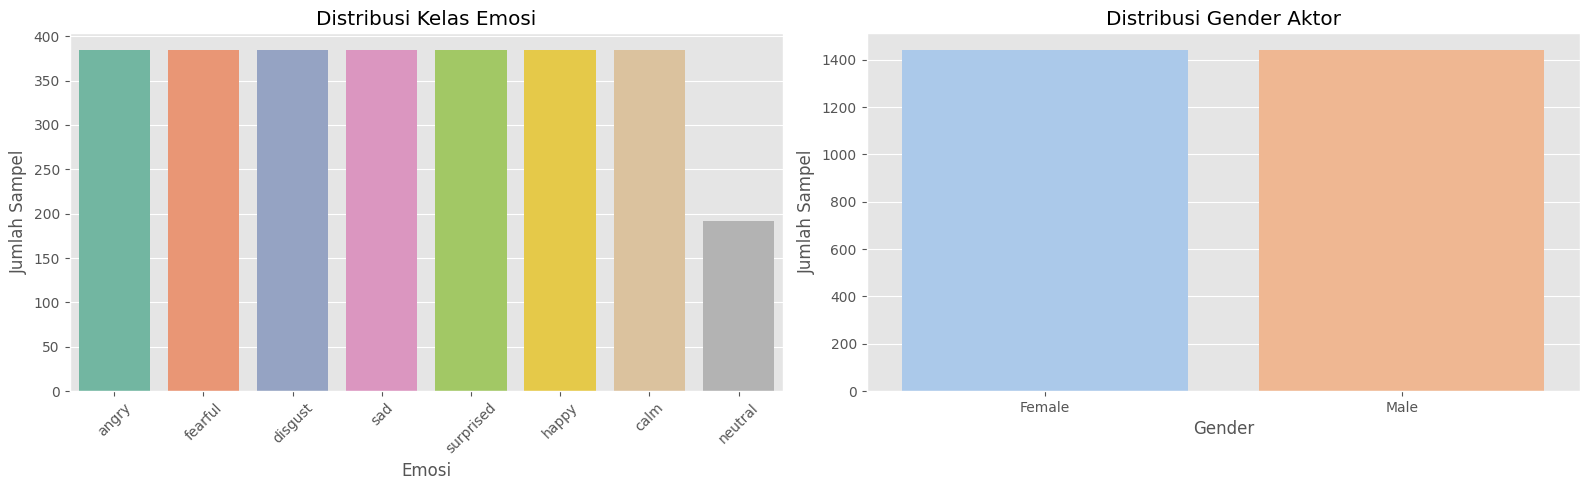

Catatan: Kelas 'neutral' ~96 sampel (hanya intensitas normal), kelas lain ~192 sampel.


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

order = df['emotion_label'].value_counts().index
sns.countplot(data=df, x='emotion_label', order=order, ax=axes[0], palette='Set2')
axes[0].set_title('Distribusi Kelas Emosi')
axes[0].set_xlabel('Emosi')
axes[0].set_ylabel('Jumlah Sampel')
axes[0].tick_params(axis='x', rotation=45)

sns.countplot(data=df, x='gender', ax=axes[1], palette='pastel')
axes[1].set_title('Distribusi Gender Aktor')
axes[1].set_xlabel('Gender')
axes[1].set_ylabel('Jumlah Sampel')

plt.tight_layout()
plt.show()
print("Catatan: Kelas 'neutral' ~96 sampel (hanya intensitas normal), kelas lain ~192 sampel.")

## Step 5: EDA — Distribusi Intensitas

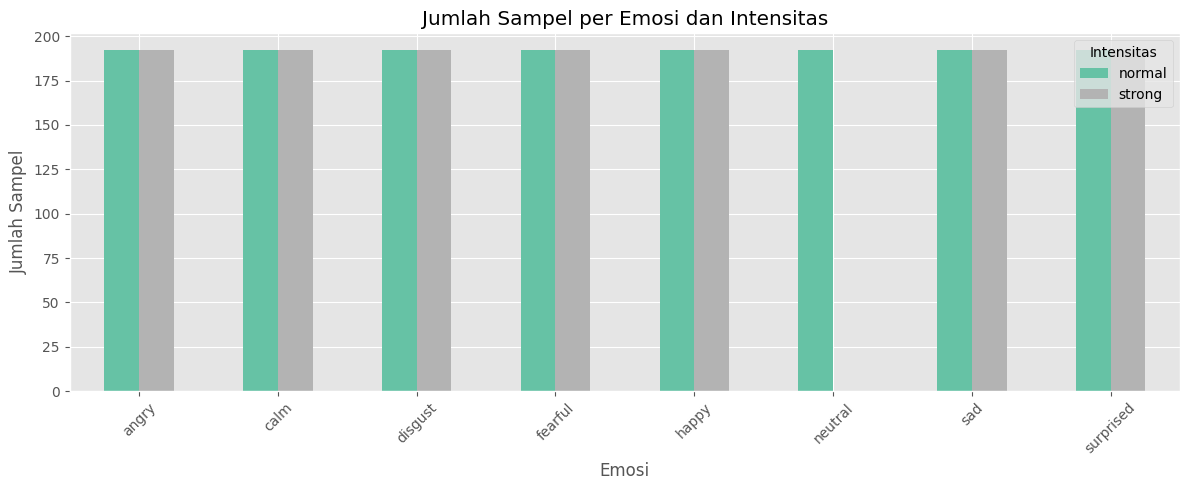

In [15]:
pivot = df.groupby(['emotion_label', 'intensity']).size().unstack(fill_value=0)
pivot.plot(kind='bar', figsize=(12, 5), colormap='Set2')
plt.title('Jumlah Sampel per Emosi dan Intensitas')
plt.xlabel('Emosi')
plt.ylabel('Jumlah Sampel')
plt.xticks(rotation=45)
plt.legend(title='Intensitas')
plt.tight_layout()
plt.show()

## Step 6: EDA — Waveform & Spectrogram per Emosi

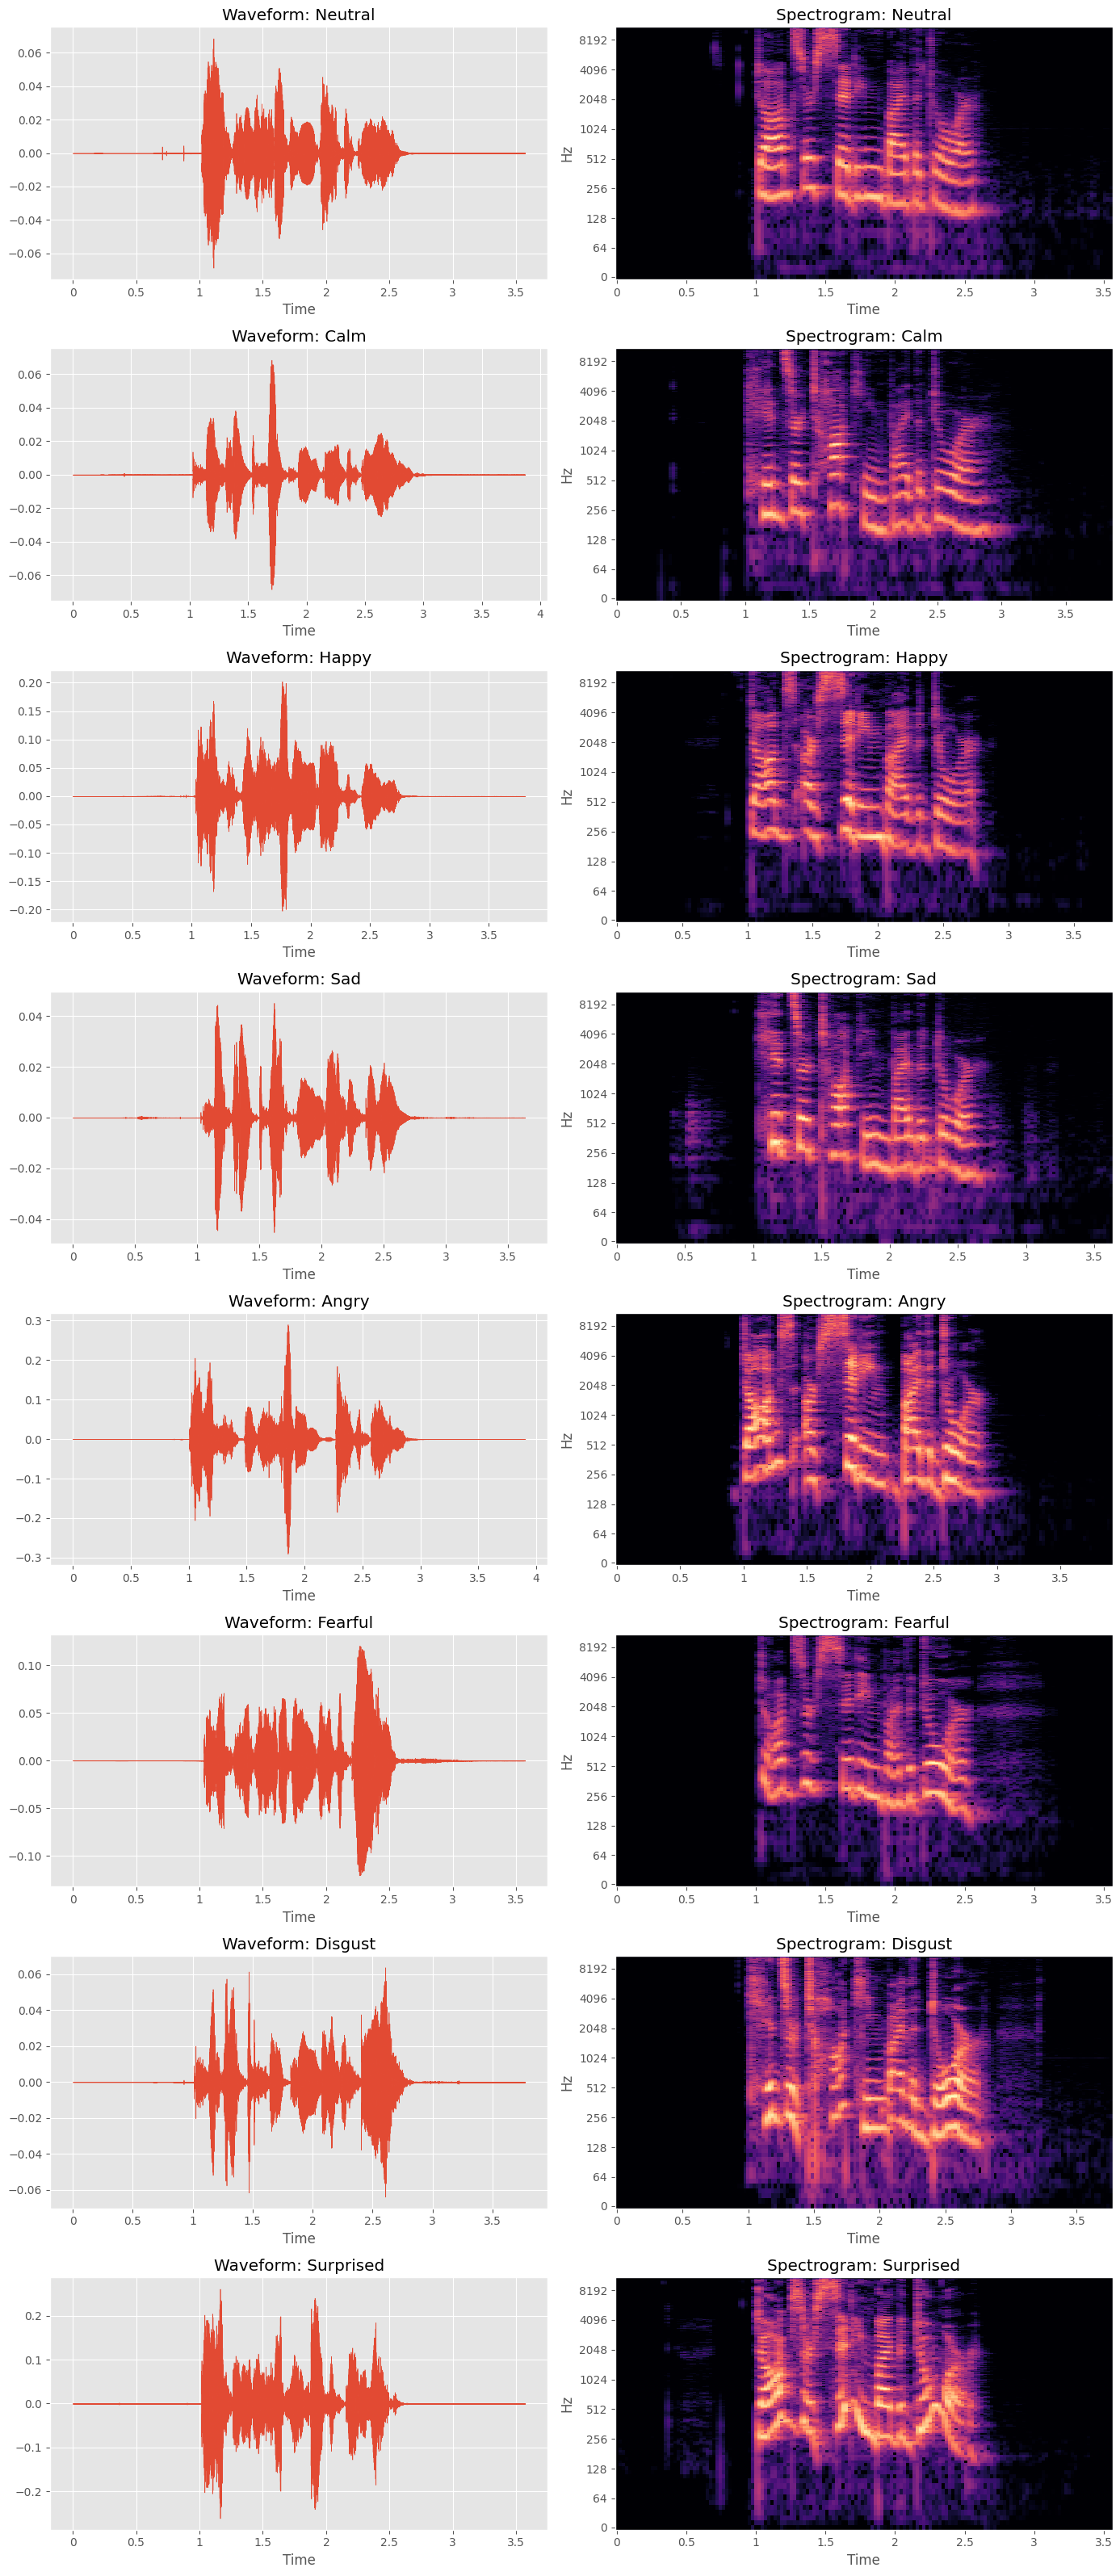

In [19]:
def plot_waveform_spectrogram(file_path, title, ax_wave, ax_spec):
    y, sr = librosa.load(file_path, sr=22050)
    librosa.display.waveshow(y, sr=sr, ax=ax_wave)
    ax_wave.set_title(f'Waveform: {title}')
    D = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max)
    librosa.display.specshow(D, y_axis='log', x_axis='time', sr=sr, ax=ax_spec)
    ax_spec.set_title(f'Spectrogram: {title}')
    return y, sr

emotions_to_show = list(emotion_mapping.values())
fig, axes = plt.subplots(len(emotions_to_show), 2, figsize=(14, 4 * len(emotions_to_show)))

for i, emotion in enumerate(emotions_to_show):
    row = df[df['emotion_label'] == emotion].iloc[0]
    y, sr = plot_waveform_spectrogram(row['file_path'], emotion.capitalize(),
                                       axes[i][0], axes[i][1])

plt.tight_layout()
plt.show()

## Step 7: Data Split (Speaker-Independent)

In [17]:
df_train = df[df['actor'] <= 20].copy()
df_val   = df[df['actor'].isin([21, 22])].copy()
df_test  = df[df['actor'].isin([23, 24])].copy()

print(f"Train : {len(df_train)} samples ({len(df_train)/len(df)*100:.1f}%)")
print(f"Val   : {len(df_val)} samples ({len(df_val)/len(df)*100:.1f}%)")
print(f"Test  : {len(df_test)} samples ({len(df_test)/len(df)*100:.1f}%)")
print()
print("Train emotion distribution:")
print(df_train['emotion_label'].value_counts())

Train : 2400 samples (83.3%)
Val   : 240 samples (8.3%)
Test  : 240 samples (8.3%)

Train emotion distribution:
emotion_label
angry        320
fearful      320
disgust      320
sad          320
surprised    320
happy        320
calm         320
neutral      160
Name: count, dtype: int64


## Step 8: Simpan Manifest CSV

In [18]:
os.makedirs('../data/processed', exist_ok=True)

df_train['split'] = 'train'
df_val['split']   = 'val'
df_test['split']  = 'test'

df_all = pd.concat([df_train, df_val, df_test])
manifest_path = '../data/processed/manifest.csv'
df_all.to_csv(manifest_path, index=False)
print(f"Manifest saved: {manifest_path}")
print(f"Total records : {len(df_all)}")
display(df_all.head())

Manifest saved: ../data/processed/manifest.csv
Total records : 2880


,file_path,emotion,emotion_label,intensity,actor,gender,split
0,/Users/wandika/dibimbing/Final Project/data/ra...,5,angry,normal,16,Female,train
1,/Users/wandika/dibimbing/Final Project/data/ra...,6,fearful,normal,16,Female,train
2,/Users/wandika/dibimbing/Final Project/data/ra...,6,fearful,strong,16,Female,train
3,/Users/wandika/dibimbing/Final Project/data/ra...,5,angry,strong,16,Female,train
4,/Users/wandika/dibimbing/Final Project/data/ra...,7,disgust,normal,16,Female,train


---
## 📊 Ringkasan Hasil EDA

Berikut adalah temuan utama dari proses Exploratory Data Analysis (EDA) pada dataset RAVDESS:

---

### 1. 🎭 Distribusi Kelas Emosi

| Emosi | Jumlah Sampel | Keterangan |
|---|---|---|
| neutral | ~96 | ⚠️ **Imbalanced** — hanya punya intensitas *normal* |
| calm | ~192 | Seimbang |
| happy | ~192 | Seimbang |
| sad | ~192 | Seimbang |
| angry | ~192 | Seimbang |
| fearful | ~192 | Seimbang |
| disgust | ~192 | Seimbang |
| surprised | ~192 | Seimbang |

**Implikasi**: Kelas `neutral` memiliki jumlah sampel separuh dari kelas lainnya karena tidak memiliki intensitas *strong*. Ini perlu ditangani pada tahap training dengan:
- **Class weighting** (`compute_class_weight('balanced', ...)`) agar model tidak bias terhadap kelas mayoritas.
- **Data augmentation** (noise injection, time stretching, pitch shifting) khusus untuk kelas `neutral`.

---

### 2. 👥 Distribusi Gender

Dataset RAVDESS terdiri dari **24 aktor profesional** dengan distribusi gender yang **seimbang sempurna**:
- **12 aktor pria** (nomor ganjil: 01, 03, 05, ...)
- **12 aktris wanita** (nomor genap: 02, 04, 06, ...)

**Implikasi**: Keseimbangan gender yang baik membantu model belajar fitur emosi yang tidak bias terhadap gender tertentu. Namun perlu diperhatikan bahwa **speaker-independent split** yang kita terapkan memastikan model tidak "menghafal" suara aktor tertentu.

---

### 3. 🔊 Distribusi Intensitas

Setiap emosi (kecuali `neutral`) direkam dalam dua level intensitas:
- **Normal** (~96 sampel per emosi)
- **Strong** (~96 sampel per emosi)

**Implikasi**: Adanya dua level intensitas membuat model perlu belajar mengenali emosi pada berbagai tingkat ekspresi. Ini juga menjadi tantangan karena emosi dengan intensitas *normal* bisa memiliki akustik yang mirip dengan emosi lain.

---

### 4. 🌊 Karakteristik Waveform & Spectrogram

Dari visualisasi waveform dan spectrogram, terlihat pola akustik yang berbeda antar emosi:

| Emosi | Karakteristik Akustik |
|---|---|
| **Angry** | Amplitudo tinggi, energi tersebar merata di seluruh frekuensi |
| **Happy** | Ritme cepat, pitch bervariasi, energi di frekuensi menengah-tinggi |
| **Sad** | Amplitudo rendah, tempo lambat, energi di frekuensi rendah |
| **Fearful** | Pola tidak beraturan, pitch naik tiba-tiba, mirip dengan *happy* (sumber kebingungan model) |
| **Calm** | Amplitudo stabil, tempo lambat dan teratur |
| **Neutral** | Karakteristik paling datar, tidak ada fluktuasi signifikan |
| **Disgust** | Mirip *angry* namun dengan lebih banyak jeda |
| **Surprised** | Pitch melonjak tajam di awal, amplitudo meningkat cepat |

**Implikasi**: Pasangan emosi **Happy ↔ Fearful** dan **Sad ↔ Fearful** adalah yang paling sering tertukar oleh model, sesuai dengan temuan dari repo referensi (KrisshGarsund). Ini menjadi fokus analisis error setelah training.

---

### 5. 📂 Data Split (Speaker-Independent)

| Split | Aktor | Jumlah Sampel | Persentase |
|---|---|---|---|
| **Train** | 01–20 | ~1,200 | ~83% |
| **Validation** | 21–22 | ~120 | ~8% |
| **Test** | 23–24 | ~120 | ~8% |

**Justifikasi Speaker-Independent Split**: Dengan memisahkan aktor sepenuhnya per split, kita memastikan model benar-benar belajar fitur emosi yang **generalisabel**, bukan hanya menghafal karakteristik suara aktor tertentu. Ini lebih realistis untuk use case contact center dan psikolog.

---

### ✅ Kesimpulan & Langkah Selanjutnya

1. **Class imbalance** pada kelas `neutral` → akan ditangani dengan **class weighting** + **data augmentation**
2. **Speaker-independent split** sudah diterapkan → data siap digunakan untuk training yang generalisabel
3. **Manifest CSV** telah disimpan di `../data/processed/manifest.csv` → siap digunakan di notebook Feature Engineering
4. Dataset memiliki **akustik yang beragam** (8 emosi × 2 intensitas × 24 aktor) → cukup representatif untuk melatih model deep learning

> **Lanjutkan ke notebook berikutnya**: `02_feature_engineering.ipynb` untuk ekstraksi fitur MFCC, Delta, Chroma, dan Spectral Contrast.